# A matemática do ruído em DDPM e DDIM no Fashion-MNIST — animações com Manim

Este notebook mostra como os coeficientes de um DDPM controlam a transformação de uma peça do Fashion-MNIST em ruído (**forward process**) e como o mesmo modelo treinado remove esse ruído com DDPM e DDIM (**backward process**). As animações usam dados reais das fórmulas em cada timestep; exibimos checkpoints representativos para manter os vídeos legíveis.

## 1. Preparação

No Ubuntu, o Manim precisa das bibliotecas nativas abaixo uma única vez:

```bash
sudo apt install libcairo2-dev libpango1.0-dev
uv sync
```

O notebook reutiliza o checkpoint criado por `ddpm_fashion_mnist_metrics.ipynb`. Vídeos e arquivos temporários ficam em `seminar_1/data/fashion_mnist/manim`.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Video
from manim import *
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
T = 1_000
FORWARD_STEPS = [0, 100, 250, 500, 750, 999]
BACKWARD_STEPS = [999, 750, 500, 250, 0]
MANIM_QUALITY = "medium_quality"
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
FASHION_DIR = ROOT / "seminar_1" / "data" / "fashion_mnist"
MANIM_DIR = FASHION_DIR / "manim"
MANIM_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS = [
    FASHION_DIR / "models" / "ddpm_50000_50.pt",
    FASHION_DIR / "models" / "ddpm_10000_20.pt",
]
CHECKPOINT = next((path for path in CHECKPOINTS if path.exists()), None)
assert CHECKPOINT is not None, "Execute primeiro ddpm_fashion_mnist_metrics.ipynb para criar o checkpoint."
print(f"device={DEVICE}; checkpoint={CHECKPOINT.name}; saída={MANIM_DIR}")

device=cpu; checkpoint=ddpm_50000_50.pt; saída=/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_1/data/fashion_mnist/manim


## 2. Schedule e processo forward

Em um passo, adicionamos uma pequena quantidade de ruído gaussiano:

$$q(x_t\mid x_{t-1})=\mathcal N(\sqrt{\alpha_t}x_{t-1},\beta_t I),\qquad \alpha_t=1-\beta_t.$$

Como o processo é gaussiano, podemos ir diretamente de $x_0$ para qualquer $x_t$:

$$x_t=\underbrace{\sqrt{\bar\alpha_t}}_{\text{sinal}}x_0+\underbrace{\sqrt{1-\bar\alpha_t}}_{\text{ruído}}\epsilon,\qquad \bar\alpha_t=\prod_{s=1}^{t}\alpha_s.$$

Usaremos o mesmo $\epsilon$ em todos os checkpoints para enxergar somente o efeito dos coeficientes.

Exemplo Fashion-MNIST: classe=9 (bota)


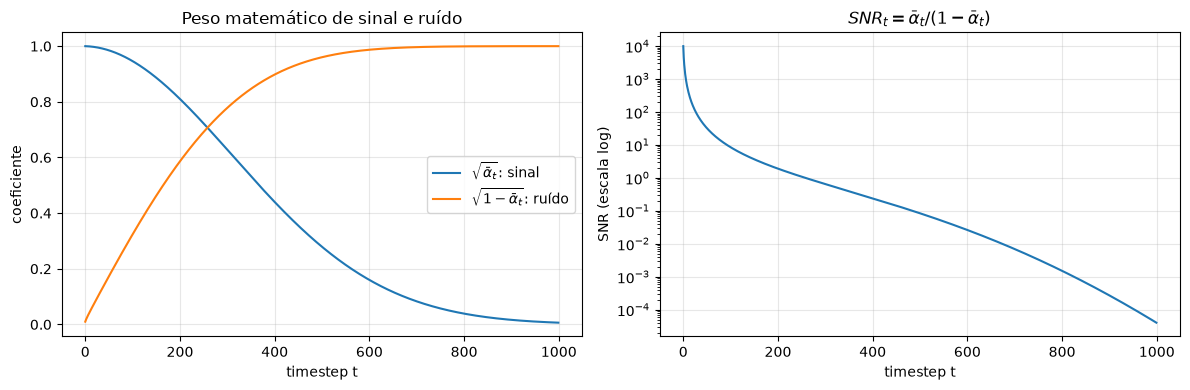

In [2]:
betas = torch.linspace(1e-4, 2e-2, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_previous = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
posterior_variance = betas * (1 - alpha_bars_previous) / (1 - alpha_bars)
signal_coefficients = alpha_bars.sqrt()
noise_coefficients = (1 - alpha_bars).sqrt()
snr = alpha_bars / (1 - alpha_bars)

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
fashion_mnist = datasets.FashionMNIST(FASHION_DIR / "source", train=False, download=False, transform=transform)
x0, x0_label = fashion_mnist[0]
x0 = x0.unsqueeze(0).to(DEVICE)
fixed_noise = torch.randn_like(x0, generator=torch.Generator(device=DEVICE).manual_seed(SEED))
forward_frames = {
    step: signal_coefficients[step] * x0 + noise_coefficients[step] * fixed_noise
    for step in FORWARD_STEPS
}
assert forward_frames[0].shape == x0.shape and signal_coefficients[-1] < 0.01
print(f"Exemplo Fashion-MNIST: classe={x0_label} (bota)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(signal_coefficients.cpu(), label=r"$\sqrt{\bar\alpha_t}$: sinal")
axes[0].plot(noise_coefficients.cpu(), label=r"$\sqrt{1-\bar\alpha_t}$: ruído")
axes[0].set(xlabel="timestep t", ylabel="coeficiente", title="Peso matemático de sinal e ruído")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].semilogy(snr.cpu())
axes[1].set(xlabel="timestep t", ylabel="SNR (escala log)", title=r"$SNR_t=\bar\alpha_t/(1-\bar\alpha_t)$")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

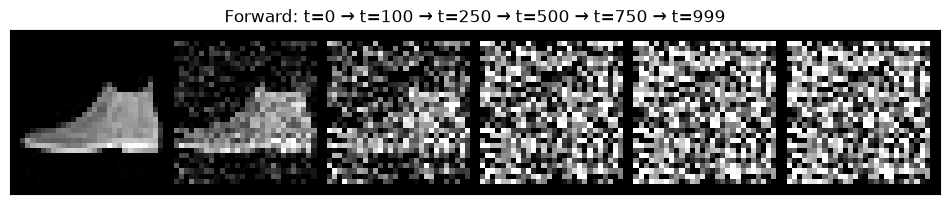

t=000: sinal=0.9999, ruído=0.0100, SNR=9997.340820
t=100: sinal=0.9461, ruído=0.3238, SNR=8.536649
t=250: sinal=0.7221, ruído=0.6918, SNR=1.089528
t=500: sinal=0.2789, ruído=0.9603, SNR=0.084360
t=750: sinal=0.0574, ruído=0.9983, SNR=0.003311
t=999: sinal=0.0064, ruído=1.0000, SNR=0.000040


In [3]:
grid = make_grid(torch.cat([forward_frames[step] for step in FORWARD_STEPS]).cpu().clamp(-1, 1), nrow=len(FORWARD_STEPS), normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 2.5))
plt.imshow(grid.permute(1, 2, 0))
plt.xticks([])
plt.yticks([])
plt.title("Forward: " + " → ".join(f"t={step}" for step in FORWARD_STEPS))
plt.show()

for step in FORWARD_STEPS:
    print(f"t={step:03d}: sinal={signal_coefficients[step]:.4f}, ruído={noise_coefficients[step]:.4f}, SNR={snr[step]:.6f}")

## 3. Animação Manim do forward

A imagem animada é o resultado numérico da fórmula mostrada na tela. Quando $\sqrt{\bar\alpha_t}$ cai, os pixels de $x_0$ deixam de influenciar $x_t$; simultaneamente, o coeficiente do ruído se aproxima de 1.

In [4]:
def tensor_to_rgb(tensor):
    gray = ((tensor.squeeze().detach().cpu().clamp(-1, 1) + 1) * 127.5).numpy().astype(np.uint8)
    return np.repeat(gray[:, :, None], 3, axis=2)

def image_mobject(tensor):
    return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)

def forward_values(step):
    return VGroup(
        MathTex(rf"t={step}"),
        MathTex(rf"\sqrt{{\bar\alpha_t}}={signal_coefficients[step].item():.4f}", color=BLUE),
        MathTex(rf"\sqrt{{1-\bar\alpha_t}}={noise_coefficients[step].item():.4f}", color=ORANGE),
        MathTex(rf"\mathrm{{SNR}}_t={snr[step].item():.4f}", color=GREEN),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.25).scale(0.72).shift(RIGHT * 3 + DOWN * 0.5)

class ForwardDiffusionScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text("Forward process: imagem → ruído", font_size=34).to_edge(UP)
        formula = MathTex(r"x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon").scale(0.78).next_to(title, DOWN)
        image = image_mobject(forward_frames[FORWARD_STEPS[0]])
        frame = SurroundingRectangle(image, color=WHITE, buff=0.08)
        values = forward_values(FORWARD_STEPS[0])
        arrow = Arrow(image.get_right(), values.get_left(), color=YELLOW, buff=0.3)
        self.play(Write(title), Write(formula))
        self.play(FadeIn(image), Create(frame), GrowArrow(arrow), FadeIn(values))
        for step in FORWARD_STEPS[1:]:
            next_image = image_mobject(forward_frames[step])
            next_values = forward_values(step)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.2)
            image = next_image
        self.wait(1)

def render_scene(scene_type):
    with tempconfig({"quality": MANIM_QUALITY, "media_dir": str(MANIM_DIR), "disable_caching": True, "preview": False}):
        scene = scene_type()
        scene.render()
        return Path(scene.renderer.file_writer.movie_file_path)

forward_video = render_scene(ForwardDiffusionScene)
Video(str(forward_video), embed=True)

/tmp/ipykernel_57988/752356389.py:6: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)


[08/12/26 09:17:27] INFO     Caching disabled.                                                 ]8;id=12857043;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857044;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:17:28] INFO     Animation 0 : Partial movie file written in                   ]8;id=12857051;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857052;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/ForwardDiffusionScene/uncached_00000.mp4'                                

                    INFO     Caching disabled.                                                 ]8;id=12857057;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857058;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:17:29] INFO     Animation 1 : Partial movie file written in                   ]8;id=12857063;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857064;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/ForwardDiffusionScene/uncached_00001.mp4'                                

...

                    INFO     Caching disabled.                                                 ]8;id=12857129;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857130;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 7 : Partial movie file written in                   ]8;id=12857135;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857136;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/ForwardDiffusionScene/uncached_00007.mp4'                                

                    INFO     Combining to Movie file.                                      ]8;id=12857142;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857143;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=12857149;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857150;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/Forward                         
                             DiffusionScene.mp4'                                                                   
                                                                                                                   

                    INFO     Rendered ForwardDiffusionScene                                            ]8;id=12857157;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=12857158;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 8 animations                                                                   

## 4. Matemática do processo backward

O modelo aprende a estimar o ruído presente em $x_t$, denotado por $\epsilon_\theta(x_t,t)$. Essa previsão entra na média da distribuição reversa:

$$\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\right).$$

Então cada passo reverso é:

$$x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}z,\qquad z\sim\mathcal N(0,I),$$

onde $\tilde\beta_t=\beta_t(1-\bar\alpha_{t-1})/(1-\bar\alpha_t)$. O primeiro termo remove o ruído previsto; o segundo mantém a amostragem probabilística.

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, size=32):
        super().__init__()
        half = size // 2
        self.register_buffer("frequencies", torch.exp(-math.log(10_000) * torch.arange(half) / (half - 1)))

    def forward(self, timesteps):
        angles = timesteps[:, None].float() * self.frequencies[None]
        return torch.cat((angles.sin(), angles.cos()), dim=1)

class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTimeEmbedding(), nn.Linear(32, 64), nn.SiLU())
        self.time1, self.time2, self.time3 = nn.Linear(64, 32), nn.Linear(64, 64), nn.Linear(64, 64)
        self.down1 = nn.Conv2d(1, 32, 3, padding=1)
        self.down2 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.down3 = nn.Conv2d(64, 64, 4, stride=2, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.output = nn.Conv2d(32, 1, 3, padding=1)
        self.norm1, self.norm5 = nn.GroupNorm(8, 32), nn.GroupNorm(8, 32)
        self.norm2, self.norm3, self.norm4 = nn.GroupNorm(8, 64), nn.GroupNorm(8, 64), nn.GroupNorm(8, 64)

    def forward(self, x, timesteps):
        embedding = self.time(timesteps)
        h1 = F.silu(self.norm1(self.down1(x) + self.time1(embedding)[:, :, None, None]))
        h2 = F.silu(self.norm2(self.down2(h1) + self.time2(embedding)[:, :, None, None]))
        h3 = F.silu(self.norm3(self.down3(h2) + self.time3(embedding)[:, :, None, None]))
        h = F.silu(self.norm4(self.up1(h3) + h2))
        h = F.silu(self.norm5(self.up2(h) + h1))
        return self.output(h)

model = TinyDenoiser().to(DEVICE)
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint.get("ema_model", checkpoint.get("model", checkpoint)))
model.eval()
assert model(torch.zeros(1, 1, 28, 28, device=DEVICE), torch.tensor([999], device=DEVICE)).shape == (1, 1, 28, 28)

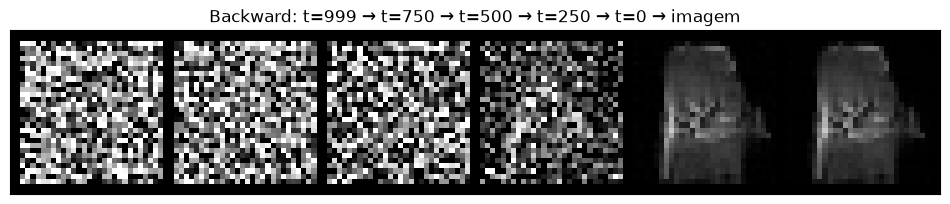

In [6]:
@torch.inference_mode()
def reverse_process(start=None, seed=SEED):
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    x = torch.randn((1, 1, 28, 28), device=DEVICE, generator=generator) if start is None else start.to(DEVICE).clone()
    frames = {}
    for step in reversed(range(T)):
        if step in BACKWARD_STEPS:
            frames[step] = x.detach().cpu()
        timesteps = torch.full((1,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        mean = (x - betas[step] / torch.sqrt(1 - alpha_bars[step]) * predicted_noise) / torch.sqrt(alphas[step])
        noise = torch.randn(x.shape, device=DEVICE, generator=generator)
        x = mean + posterior_variance[step].sqrt() * noise if step > 0 else mean
    frames["final"] = x.detach().cpu().clamp(-1, 1)
    return frames

backward_frames = reverse_process()
cycle_backward_frames = reverse_process(forward_frames[FORWARD_STEPS[-1]], seed=SEED + 2)
assert torch.equal(cycle_backward_frames[999], forward_frames[999].cpu())
backward_order = BACKWARD_STEPS + ["final"]
grid = make_grid(torch.cat([backward_frames[step] for step in backward_order]), nrow=len(backward_order), normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 2.5))
plt.imshow(grid.permute(1, 2, 0))
plt.xticks([])
plt.yticks([])
plt.title("Backward: " + " → ".join("imagem" if step == "final" else f"t={step}" for step in backward_order))
plt.show()

## 5. Animação Manim do backward

A rede é avaliada em todos os 1.000 timesteps. A animação mostra apenas cinco estados intermediários e o resultado final; portanto, nenhum passo matemático é pulado durante a geração.

In [7]:
def backward_values(step):
    if step == "final":
        return VGroup(Text("imagem gerada", font_size=30), MathTex(r"x_0\sim p_\theta(x_0)", color=GREEN)).arrange(DOWN, buff=0.3).shift(RIGHT * 3 + DOWN * 0.5)
    removal = (betas[step] / torch.sqrt(1 - alpha_bars[step])).item()
    stochasticity = posterior_variance[step].sqrt().item()
    return VGroup(
        MathTex(rf"t={step}"),
        MathTex(rf"\frac{{\beta_t}}{{\sqrt{{1-\bar\alpha_t}}}}={removal:.5f}", color=BLUE),
        MathTex(rf"\sqrt{{\tilde\beta_t}}={stochasticity:.5f}", color=ORANGE),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.3).scale(0.75).shift(RIGHT * 3 + DOWN * 0.5)

class BackwardDiffusionScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text("Backward process: ruído → imagem", font_size=34).to_edge(UP)
        formula = MathTex(r"x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}z").scale(0.82).next_to(title, DOWN)
        image = image_mobject(backward_frames[backward_order[0]])
        frame = SurroundingRectangle(image, color=WHITE, buff=0.08)
        values = backward_values(backward_order[0])
        arrow = Arrow(values.get_left(), image.get_right(), color=YELLOW, buff=0.3)
        self.play(Write(title), Write(formula))
        self.play(FadeIn(image), Create(frame), GrowArrow(arrow), FadeIn(values))
        for step in backward_order[1:]:
            next_image = image_mobject(backward_frames[step])
            next_values = backward_values(step)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.2)
            image = next_image
        self.wait(1)

backward_video = render_scene(BackwardDiffusionScene)
Video(str(backward_video), embed=True)

/tmp/ipykernel_57988/752356389.py:6: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)


[08/12/26 09:17:39] INFO     Caching disabled.                                                 ]8;id=12857163;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857164;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 0 : Partial movie file written in                   ]8;id=12857169;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857170;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/BackwardDiffusionScene/uncached_00000.mp4'                               

                    INFO     Caching disabled.                                                 ]8;id=12857175;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857176;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:17:40] INFO     Animation 1 : Partial movie file written in                   ]8;id=12857181;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857182;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/BackwardDiffusionScene/uncached_00001.mp4'                               

...

                    INFO     Caching disabled.                                                 ]8;id=12857247;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857248;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 7 : Partial movie file written in                   ]8;id=12857253;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857254;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/BackwardDiffusionScene/uncached_00007.mp4'                               

                    INFO     Combining to Movie file.                                      ]8;id=12857259;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857260;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=12857265;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857266;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/Backwar                         
                             dDiffusionScene.mp4'                                                                  
                                                                                                                   

                    INFO     Rendered BackwardDiffusionScene                                           ]8;id=12857271;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=12857272;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 8 animations                                                                   

## 6. DDIM em 250 passos com $\eta=1$

O DDIM reutiliza a mesma rede $\epsilon_\theta$ treinada pelo DDPM, mas percorre uma sequência reduzida $\tau$ de timesteps. Primeiro estimamos a imagem limpa:

$$\hat{x}_0=\frac{x_{\tau_i}-\sqrt{1-\bar\alpha_{\tau_i}}\,\epsilon_\theta(x_{\tau_i},\tau_i)}{\sqrt{\bar\alpha_{\tau_i}}}.$$

O parâmetro $\eta$ controla a estocasticidade. Para este checkpoint pequeno, $\eta=1$ produziu uma imagem mais limpa que a trajetória determinística. A variância de cada salto é:

$$\sigma_{\tau_i}=\eta\sqrt{\frac{1-\bar\alpha_{\tau_{i-1}}}{1-\bar\alpha_{\tau_i}}\left(1-\frac{\bar\alpha_{\tau_i}}{\bar\alpha_{\tau_{i-1}}}\right)},$$

$$x_{\tau_{i-1}}=\sqrt{\bar\alpha_{\tau_{i-1}}}\,\hat{x}_0+\sqrt{1-\bar\alpha_{\tau_{i-1}}-\sigma_{\tau_i}^2}\,\epsilon_\theta+\sigma_{\tau_i}z.$$

Para tornar a comparação direta, DDIM e DDPM começam exatamente no mesmo tensor de ruído $x_T$.

### Diferença entre $T$, $t$ e quantidade de passos

| Símbolo/parâmetro | Significado neste notebook |
|---|---|
| $T=1000$ | Quantidade de níveis de ruído usados no treinamento. Esse schedule permanece o mesmo para DDPM e DDIM. |
| $t$ | Nível de ruído atual, entre 999 (quase ruído puro) e 0 (imagem quase limpa). Ele seleciona $\bar\alpha_t$ e é informado à rede. |
| $i$ | Posição dentro da trajetória de amostragem; conta quantos passos já foram executados. |
| `DDIM_STEPS=250` | Quantidade de valores de $t$ escolhidos pelo DDIM e, portanto, quantidade de avaliações da rede. |

O DDPM visita todos os valores $999,998,\ldots,0$ e faz 1.000 avaliações. O DDIM mantém o mesmo eixo de ruído, mas seleciona somente 250 valores $\tau_i$ aproximadamente espaçados:

$$\tau_i=\left\lfloor999\left(1-\frac{i}{249}\right)\right\rfloor,\qquad i=0,\ldots,249.$$

Por exemplo, próximo de $t=500$, o DDPM já executou cerca de 499 passos, enquanto o DDIM executou cerca de 124. Assim, **$t$ mede o nível de ruído**, enquanto **a contagem de passos mede o custo de geração**. Aumentar `DDIM_STEPS` cria saltos menores entre valores de $t$, mas também aumenta o tempo de execução e não garante melhoria se o preditor de ruído for limitado.

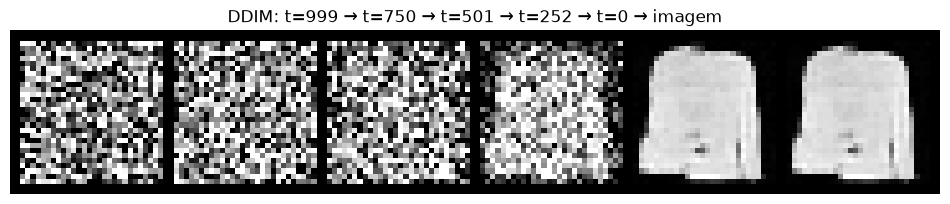

In [8]:
DDIM_STEPS = 250
DDIM_ETA = 1.0
DDIM_FRAME_INDICES = np.linspace(0, DDIM_STEPS - 1, len(BACKWARD_STEPS), dtype=int).tolist()

@torch.inference_mode()
def ddim_process():
    schedule = torch.linspace(T - 1, 0, DDIM_STEPS, device=DEVICE).long()
    assert torch.all(schedule[:-1] > schedule[1:])
    x = backward_frames[BACKWARD_STEPS[0]].to(DEVICE).clone()
    generator = torch.Generator(device=DEVICE).manual_seed(SEED + 1)
    frames = []

    for index, step_tensor in enumerate(schedule):
        step = int(step_tensor.item())
        alpha_bar = alpha_bars[step]
        previous_alpha_bar = alpha_bars[schedule[index + 1]] if index + 1 < DDIM_STEPS else torch.tensor(1.0, device=DEVICE)
        sigma = DDIM_ETA * torch.sqrt((1 - previous_alpha_bar) / (1 - alpha_bar) * (1 - alpha_bar / previous_alpha_bar))
        if index in DDIM_FRAME_INDICES:
            frames.append({"step": step, "evaluation": index, "sigma": sigma.item(), "image": x.detach().cpu()})

        timesteps = torch.full((1,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        predicted_x0 = (x - torch.sqrt(1 - alpha_bar) * predicted_noise) / torch.sqrt(alpha_bar)
        direction = torch.sqrt(torch.clamp(1 - previous_alpha_bar - sigma.square(), min=0)) * predicted_noise
        noise = torch.randn(x.shape, device=DEVICE, generator=generator) if DDIM_ETA > 0 else 0.0
        x = torch.sqrt(previous_alpha_bar) * predicted_x0 + direction + sigma * noise

    frames.append({"step": "final", "evaluation": DDIM_STEPS, "image": x.detach().cpu().clamp(-1, 1)})
    return frames

ddim_frames = ddim_process()
assert len(ddim_frames) == len(backward_order)
assert torch.equal(ddim_frames[0]["image"], backward_frames[BACKWARD_STEPS[0]])

grid = make_grid(torch.cat([frame["image"] for frame in ddim_frames]), nrow=len(ddim_frames), normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 2.5))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("DDIM: " + " → ".join("imagem" if frame["step"] == "final" else "t={}".format(frame["step"]) for frame in ddim_frames))
plt.show()

In [9]:
def ddim_values(frame):
    if frame["step"] == "final":
        return VGroup(
            Text("imagem gerada", font_size=30),
            MathTex(rf"{DDIM_STEPS}\;\text{{avaliações da rede}}", color=GREEN),
        ).arrange(DOWN, buff=0.3).shift(RIGHT * 3 + DOWN * 0.7)
    return VGroup(
        MathTex(rf"t={frame['step']}"),
        MathTex(rf"\text{{avaliações}}={frame['evaluation']}/{DDIM_STEPS}", color=BLUE),
        MathTex(rf"\eta={DDIM_ETA:g},\;\sigma_t={frame['sigma']:.4f}", color=ORANGE),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.3).scale(0.75).shift(RIGHT * 3 + DOWN * 0.7)

class DDIMDiffusionScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text(f"DDIM: ruído → imagem em {DDIM_STEPS} passos", font_size=34).to_edge(UP)
        formula = MathTex(
            r"x_{\tau_{i-1}}=\sqrt{\bar\alpha_{\tau_{i-1}}}\hat{x}_0"
            r"+\sqrt{1-\bar\alpha_{\tau_{i-1}}-\sigma_t^2}\epsilon_\theta+\sigma_tz"
        ).scale(0.58).next_to(title, DOWN)
        legend = Text("t: nível de ruído · avaliações: passos já executados", font_size=21).to_edge(DOWN)
        image = image_mobject(ddim_frames[0]["image"])
        frame_box = SurroundingRectangle(image, color=WHITE, buff=0.08)
        values = ddim_values(ddim_frames[0])
        arrow = Arrow(values.get_left(), image.get_right(), color=YELLOW, buff=0.3)
        self.play(Write(title), Write(formula), FadeIn(legend))
        self.play(FadeIn(image), Create(frame_box), GrowArrow(arrow), FadeIn(values))
        for ddim_frame in ddim_frames[1:]:
            next_image = image_mobject(ddim_frame["image"])
            next_values = ddim_values(ddim_frame)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.2)
            image = next_image
        self.wait(1)

ddim_video = render_scene(DDIMDiffusionScene)
Video(str(ddim_video), embed=True)

/tmp/ipykernel_57988/752356389.py:6: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)


[08/12/26 09:17:49] INFO     Caching disabled.                                                 ]8;id=12857277;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857278;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:17:50] INFO     Animation 0 : Partial movie file written in                   ]8;id=12857283;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857284;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/DDIMDiffusionScene/uncached_00000.mp4'                                   

                    INFO     Caching disabled.                                                 ]8;id=12857289;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857290;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:17:51] INFO     Animation 1 : Partial movie file written in                   ]8;id=12857295;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857296;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/DDIMDiffusionScene/uncached_00001.mp4'                                   

...

                    INFO     Caching disabled.                                                 ]8;id=12857361;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857362;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 7 : Partial movie file written in                   ]8;id=12857367;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857368;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/DDIMDiffusionScene/uncached_00007.mp4'                                   

                    INFO     Combining to Movie file.                                      ]8;id=12857373;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857374;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=12857379;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857380;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/DDIMDif                         
                             fusionScene.mp4'                                                                      
                                                                                                                   

                    INFO     Rendered DDIMDiffusionScene                                               ]8;id=12857385;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=12857386;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 8 animations                                                                   

## 7. Vídeo comparativo: DDPM × DDIM

Os quadros são sincronizados pelo progresso da trajetória. As duas colunas usam o mesmo ruído inicial e a mesma rede; muda apenas a regra de amostragem.

In [10]:
ddpm_comparison_frames = [
    {
        "step": step,
        "evaluation": T if step == "final" else T - 1 - step,
        "image": backward_frames[step],
    }
    for step in backward_order
]

def comparison_image(tensor, x_position):
    return ImageMobject(tensor_to_rgb(tensor)).set_height(3.1).move_to([x_position, -0.35, 0])

def comparison_label(name, frame, total, color):
    step = "imagem final" if frame["step"] == "final" else "t={}".format(frame["step"])
    return VGroup(
        Text(step, font_size=25, color=color),
        Text("{}/{} avaliações".format(frame["evaluation"], total), font_size=22),
    ).arrange(DOWN, buff=0.12)

class DDPMvsDDIMScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text("DDPM × DDIM", font_size=38).to_edge(UP)
        subtitle = Text("Mesmo ruído inicial e mesma rede", font_size=24).next_to(title, DOWN, buff=0.12)
        parameter_note = Text("t = nível de ruído · avaliações = custo da geração", font_size=20).next_to(subtitle, DOWN, buff=0.08)
        ddpm_heading = Text("DDPM · estocástico · 1.000 passos", font_size=25, color=BLUE).move_to([-3.25, 1.45, 0])
        ddim_heading = Text(f"DDIM · η={DDIM_ETA:g} · {DDIM_STEPS} passos", font_size=25, color=ORANGE).move_to([3.25, 1.45, 0])
        divider = Line([0, 1.65, 0], [0, -3.2, 0], color=GRAY)

        ddpm_image = comparison_image(ddpm_comparison_frames[0]["image"], -3.25)
        ddim_image = comparison_image(ddim_frames[0]["image"], 3.25)
        ddpm_label = comparison_label("DDPM", ddpm_comparison_frames[0], T, BLUE).next_to(ddpm_image, DOWN)
        ddim_label = comparison_label("DDIM", ddim_frames[0], DDIM_STEPS, ORANGE).next_to(ddim_image, DOWN)

        self.play(Write(title), FadeIn(subtitle, parameter_note), FadeIn(ddpm_heading, ddim_heading), Create(divider))
        self.play(FadeIn(ddpm_image, ddim_image), FadeIn(ddpm_label, ddim_label))

        for ddpm_frame, ddim_frame in zip(ddpm_comparison_frames[1:], ddim_frames[1:]):
            next_ddpm_image = comparison_image(ddpm_frame["image"], -3.25)
            next_ddim_image = comparison_image(ddim_frame["image"], 3.25)
            next_ddpm_label = comparison_label("DDPM", ddpm_frame, T, BLUE).next_to(next_ddpm_image, DOWN)
            next_ddim_label = comparison_label("DDIM", ddim_frame, DDIM_STEPS, ORANGE).next_to(next_ddim_image, DOWN)
            self.play(
                FadeTransform(ddpm_image, next_ddpm_image),
                FadeTransform(ddim_image, next_ddim_image),
                Transform(ddpm_label, next_ddpm_label),
                Transform(ddim_label, next_ddim_label),
                run_time=1.3,
            )
            ddpm_image, ddim_image = next_ddpm_image, next_ddim_image
        self.wait(1)

comparison_video = render_scene(DDPMvsDDIMScene)
Video(str(comparison_video), embed=True)

/tmp/ipykernel_57988/1419218936.py:11: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.1).move_to([x_position, -0.35, 0])


[08/12/26 09:18:00] INFO     Caching disabled.                                                 ]8;id=12857391;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857392;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:18:01] INFO     Animation 0 : Partial movie file written in                   ]8;id=12857397;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857398;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/DDPMvsDDIMScene/uncached_00000.mp4'                                      

                    INFO     Caching disabled.                                                 ]8;id=12857403;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857404;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 1 : Partial movie file written in                   ]8;id=12857409;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857410;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/DDPMvsDDIMScene/uncached_00001.mp4'                                      

...

                    INFO     Caching disabled.                                                 ]8;id=12857475;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857476;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 7 : Partial movie file written in                   ]8;id=12857481;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857482;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/DDPMvsDDIMScene/uncached_00007.mp4'                                      

                    INFO     Combining to Movie file.                                      ]8;id=12857487;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857488;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=12857493;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857494;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/DDPMvsD                         
                             DIMScene.mp4'                                                                         
                                                                                                                   

                    INFO     Rendered DDPMvsDDIMScene                                                  ]8;id=12857499;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=12857500;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 8 animations                                                                   

## 8. Vídeo completo do DDPM: forward, backward e fluxograma

Neste vídeo, o backward começa exatamente no $x_{999}$ produzido pelo forward. Portanto, o quadro de ruído que encerra a primeira fase é o mesmo que inicia a segunda. O forward usa a fórmula fechada para calcular os checkpoints; o backward executa todos os 1.000 passos da rede, embora a animação mostre apenas estados representativos.

Isso é diferente da comparação DDPM × DDIM anterior: nela os dois samplers também compartilham o mesmo $x_T$, mas esse tensor é sorteado diretamente de $\mathcal N(0,I)$, como ocorre na geração comum. Como o forward destrói informação, o backward produz uma nova imagem plausível, mas não garante reconstruir a mesma peça original.

In [11]:
def journey_values(phase, step, completed, total, color):
    if step == "final":
        return VGroup(
            Text("imagem gerada", font_size=28, color=color),
            Text(f"{total}/{total} passos executados", font_size=22),
        ).arrange(DOWN, buff=0.25).shift(RIGHT * 3 + DOWN * 0.5)
    return VGroup(
        Text(phase, font_size=27, color=color),
        MathTex(rf"t={step}"),
        Text(f"{completed}/{total} passos executados", font_size=22),
    ).arrange(DOWN, buff=0.22).shift(RIGHT * 3 + DOWN * 0.5)

def timeline_frame(tensor, label, progress, center, color):
    image = ImageMobject(tensor_to_rgb(tensor)).set_height(1.22).move_to(center)
    border = SurroundingRectangle(image, color=color, buff=0.04)
    caption = VGroup(
        MathTex(label, color=color).scale(0.56),
        Text(progress, font_size=15),
    ).arrange(DOWN, buff=0.04).next_to(image, DOWN, buff=0.08)
    return Group(image, border, caption)

class CompleteDDPMScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text("1. Forward DDPM: imagem → ruído", font_size=34).to_edge(UP)
        formula = MathTex(r"x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon").scale(0.76).next_to(title, DOWN)
        image = image_mobject(forward_frames[FORWARD_STEPS[0]])
        frame_box = SurroundingRectangle(image, color=ORANGE, buff=0.08)
        values = journey_values("adição de ruído", FORWARD_STEPS[0], 0, T, ORANGE)
        legend = Text("t: nível de ruído · passos: progresso no schedule", font_size=21).to_edge(DOWN)

        self.play(Write(title), Write(formula), FadeIn(legend))
        self.play(FadeIn(image), Create(frame_box), FadeIn(values))
        for step in FORWARD_STEPS[1:]:
            next_image = image_mobject(forward_frames[step])
            next_values = journey_values("adição de ruído", step, step, T, ORANGE)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.05)
            image = next_image

        backward_title = Text("2. Backward DDPM: ruído → imagem", font_size=34).to_edge(UP)
        backward_formula = MathTex(r"x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}z").scale(0.8).next_to(backward_title, DOWN)
        backward_values_group = journey_values("remoção de ruído", 999, 0, T, BLUE)
        self.play(
            Transform(title, backward_title),
            Transform(formula, backward_formula),
            Transform(values, backward_values_group),
            frame_box.animate.set_color(BLUE),
        )
        for step in backward_order[1:]:
            completed = T if step == "final" else T - 1 - step
            next_image = image_mobject(cycle_backward_frames[step])
            next_values = journey_values("remoção de ruído", step, completed, T, BLUE)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.05)
            image = next_image
        self.wait(0.8)

        self.play(FadeOut(title, formula, image, frame_box, values, legend))
        flow_title = Text("3. Fluxograma visual: imagem → ruído → imagem", font_size=34).to_edge(UP)
        x_positions = [-5.5, -3.3, -1.1, 1.1, 3.3, 5.5]
        forward_items = [
            timeline_frame(x0, r"x_0", "imagem original", [x_positions[0], 1.35, 0], GREEN),
            *[
                timeline_frame(forward_frames[step], rf"t={step}", f"{step}/1000 passos", [x, 1.35, 0], ORANGE)
                for x, step in zip(x_positions[1:], FORWARD_STEPS[1:])
            ],
        ]
        backward_items = [
            timeline_frame(
                cycle_backward_frames[step],
                r"\hat{x}_0" if step == "final" else rf"t={step}",
                "1000/1000 passos" if step == "final" else f"{T - 1 - step}/1000 passos",
                [x, -1.55, 0],
                GREEN if step == "final" else BLUE,
            )
            for x, step in zip(reversed(x_positions), backward_order)
        ]
        forward_label = Text("FORWARD: características desaparecem", font_size=22, color=ORANGE).move_to([0, 2.45, 0])
        backward_label = Text("BACKWARD: a rede remove o ruído em cada t", font_size=22, color=BLUE).move_to([0, -0.4, 0])
        forward_arrows = [
            Arrow([x_positions[i] + 0.72, 1.35, 0], [x_positions[i + 1] - 0.72, 1.35, 0], buff=0, color=ORANGE)
            for i in range(len(x_positions) - 1)
        ]
        backward_x = list(reversed(x_positions))
        backward_arrows = [
            Arrow([backward_x[i] - 0.72, -1.55, 0], [backward_x[i + 1] + 0.72, -1.55, 0], buff=0, color=BLUE)
            for i in range(len(backward_x) - 1)
        ]
        connection = VGroup(
            Line([6.15, 1.35, 0], [6.45, 1.35, 0], color=YELLOW),
            Arrow([6.45, 1.35, 0], [6.45, -1.55, 0], buff=0, color=YELLOW),
            Arrow([6.45, -1.55, 0], [6.15, -1.55, 0], buff=0, color=YELLOW),
        )
        continuity = Text("Mesmo x₉₉₉ · todos os 1.000 passos são calculados", font_size=20).to_edge(DOWN)

        self.play(Write(flow_title), FadeIn(forward_label), FadeIn(forward_items[0]))
        for arrow, item in zip(forward_arrows, forward_items[1:]):
            self.play(GrowArrow(arrow), FadeIn(item), run_time=0.55)
        self.play(Create(connection), FadeIn(backward_label), FadeIn(backward_items[0]))
        for arrow, item in zip(backward_arrows, backward_items[1:]):
            self.play(GrowArrow(arrow), FadeIn(item), run_time=0.55)
        self.play(FadeIn(continuity))
        self.wait(2)

complete_ddpm_video = render_scene(CompleteDDPMScene)
Video(str(complete_ddpm_video), embed=True)

/tmp/ipykernel_57988/752356389.py:6: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)


[08/12/26 09:18:11] INFO     Caching disabled.                                                 ]8;id=12857505;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857506;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

[08/12/26 09:18:12] INFO     Animation 0 : Partial movie file written in                   ]8;id=12857511;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857512;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/CompleteDDPMScene/uncached_00000.mp4'                                    

                    INFO     Caching disabled.                                                 ]8;id=12857517;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857518;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 1 : Partial movie file written in                   ]8;id=12857523;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857524;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/CompleteDDPMScene/uncached_00001.mp4'                                    

...

                    INFO     Caching disabled.                                                 ]8;id=12857841;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=12857842;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 28 : Partial movie file written in                  ]8;id=12857847;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857848;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/partial                         
                             _movie_files/CompleteDDPMScene/uncached_00028.mp4'                                    

                    INFO     Combining to Movie file.                                      ]8;id=12857853;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857854;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=12857859;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=12857860;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/fashion_mnist/manim/videos/720p30/Complet                         
                             eDDPMScene.mp4'                                                                       
                                                                                                                   

                    INFO     Rendered CompleteDDPMScene                                                ]8;id=12857865;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=12857866;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 29 animations                                                                  

## 9. Leitura dos resultados

- No forward, o schedule não adiciona simplesmente uma opacidade: ele reduz matematicamente o sinal e aumenta a variância do ruído.
- A SNR cai várias ordens de grandeza; por isso timesteps iniciais preservam o contorno da peça e timesteps finais se aproximam de uma normal padrão.
- No backward, $\epsilon_\theta$ decide qual componente remover, enquanto $\tilde\beta_t$ controla a aleatoriedade restante.
- O DDIM usa a mesma previsão de ruído, mas salta timesteps; neste checkpoint, $\eta=1$ preservou uma parcela estocástica e produziu uma imagem mais limpa.
- No vídeo comparativo, o DDIM chega à imagem com 250 avaliações da rede, enquanto o DDPM executa 1.000 avaliações.
- O checkpoint Fashion-MNIST usado foi treinado por 50 épocas com 50.000 imagens e atingiu MSE de validação de aproximadamente $0{,}0472$.
- O processo reverso depende do modelo treinado: as fórmulas definem o caminho, mas a qualidade de $\epsilon_\theta$ determina a qualidade da imagem final.